# Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import brier_score_loss, confusion_matrix, classification_report, accuracy_score
import xgboost as xgb
import warnings

warnings.simplefilter('ignore')
DATA_DIR = "nba_dataset_2004/"

# Functions for Data Extraction and Engineering

In [4]:
def load_seeds(prefix):
    seeds = pd.read_csv(f"{DATA_DIR}{prefix}NCAATourneySeeds.csv")
    seeds['SeedInt'] = seeds['Seed'].apply(lambda x: int(x[1:3]))
    return seeds[['Season', 'TeamID', 'SeedInt']]

def extract_sota_rankings():
    try:
        massey = pd.read_csv(f"{DATA_DIR}MMasseyOrdinals.csv")
        sota_systems = ['POM', 'SAG', 'BPI', 'MOR']
        final_rankings = massey[(massey['RankingDayNum'] == 133) & (massey['SystemName'].isin(sota_systems))]
        if len(final_rankings) < 100: 
            final_rankings = massey[massey['RankingDayNum'] == 133]
        median_ranks = final_rankings.groupby(['Season', 'TeamID'])['OrdinalRank'].median().reset_index()
        median_ranks.rename(columns={'OrdinalRank': 'Rank_SOTA'}, inplace=True)
        return median_ranks
    except Exception:
        return pd.DataFrame(columns=['Season', 'TeamID', 'Rank_SOTA'])

def extract_advanced_metrics(prefix):
    try:
        reg = pd.read_csv(f"{DATA_DIR}{prefix}RegularSeasonDetailedResults.csv")
        reg['Poss'] = 0.96 * (reg['WFGA'] - reg['WOR'] + reg['WTO'] + (0.44 * reg['WFTA']))
    except FileNotFoundError:
        return pd.DataFrame(columns=['Season', 'TeamID', 'WinRatio', 'NetRtg', 'ORtg', 'DRtg'])
        
    win_stats = reg.groupby(['Season', 'WTeamID']).agg(
        Wins=('WTeamID', 'count'), WPoints=('WScore', 'sum'), WPoss=('Poss', 'sum'),
        Opp_LPoints=('LScore', 'sum'), Opp_LPoss=('Poss', 'sum') 
    ).reset_index().rename(columns={'WTeamID': 'TeamID'})
    
    loss_stats = reg.groupby(['Season', 'LTeamID']).agg(
        Losses=('LTeamID', 'count'), LPoints=('LScore', 'sum'), LPoss=('Poss', 'sum'),
        Opp_WPoints=('WScore', 'sum'), Opp_WPoss=('Poss', 'sum')
    ).reset_index().rename(columns={'LTeamID': 'TeamID'})

    stats = pd.merge(win_stats, loss_stats, on=['Season', 'TeamID'], how='outer').fillna(0)
    stats['Games'] = stats['Wins'] + stats['Losses']
    stats['WinRatio'] = stats['Wins'] / stats['Games']
    
    total_pts_scored = stats['WPoints'] + stats['LPoints']
    total_pts_allowed = stats['Opp_LPoints'] + stats['Opp_WPoints']
    total_possessions = (stats['WPoss'] + stats['LPoss']).replace(0, 1)
    total_opp_possessions = (stats['Opp_LPoss'] + stats['Opp_WPoss']).replace(0, 1)
    
    stats['ORtg'] = 100 * (total_pts_scored / total_possessions)
    stats['DRtg'] = 100 * (total_pts_allowed / total_opp_possessions)
    stats['NetRtg'] = stats['ORtg'] - stats['DRtg']

    return stats[['Season', 'TeamID', 'WinRatio', 'NetRtg', 'ORtg', 'DRtg']]

def build_training_data(prefix):
    stats = extract_advanced_metrics(prefix)
    seeds = load_seeds(prefix)
    features = pd.merge(stats, seeds, on=['Season', 'TeamID'], how='left')
    features['SeedInt'] = features['SeedInt'].fillna(17) 
    
    if prefix == 'M':
        rankings = extract_sota_rankings()
        features = pd.merge(features, rankings, on=['Season', 'TeamID'], how='left')
        features['Rank_SOTA'] = features['Rank_SOTA'].fillna(175).astype(float)
    else:
        features['Rank_SOTA'] = features['SeedInt'] * 11.0 
        
    tourney = pd.read_csv(f"{DATA_DIR}{prefix}NCAATourneyCompactResults.csv")
    
    df1 = tourney[['Season', 'WTeamID', 'LTeamID']].copy()
    df1.rename(columns={'WTeamID': 'TeamA', 'LTeamID': 'TeamB'}, inplace=True)
    df1['Target'] = 1
    
    df2 = tourney[['Season', 'LTeamID', 'WTeamID']].copy()
    df2.rename(columns={'LTeamID': 'TeamA', 'WTeamID': 'TeamB'}, inplace=True)
    df2['Target'] = 0
    
    train_df = pd.concat([df1, df2], ignore_index=True)
    train_df = pd.merge(train_df, features, left_on=['Season', 'TeamA'], right_on=['Season', 'TeamID'], how='left').drop(columns=['TeamID'])
    train_df.rename(columns=lambda x: f"{x}_A" if x not in ['Season','TeamA','TeamB','Target'] else x, inplace=True)
    train_df = pd.merge(train_df, features, left_on=['Season', 'TeamB'], right_on=['Season', 'TeamID'], how='left').drop(columns=['TeamID'])
    train_df.rename(columns=lambda x: f"{x}_B" if x not in ['Season','TeamA','TeamB','Target'] and not x.endswith('_A') else x, inplace=True)
    
    train_df['Diff_Seed'] = train_df['SeedInt_A'] - train_df['SeedInt_B']
    train_df['Diff_WinRatio'] = train_df['WinRatio_A'] - train_df['WinRatio_B']
    train_df['Diff_NetRtg'] = train_df['NetRtg_A'] - train_df['NetRtg_B']
    train_df['Diff_Rank'] = train_df['Rank_SOTA_A'] - train_df['Rank_SOTA_B']

    train_df.dropna(inplace=True)
    return train_df, features

# Process Data and Split for Validation

In [5]:
m_train, m_features = build_training_data('M')
w_train, w_features = build_training_data('W')

train_df = pd.concat([m_train, w_train], ignore_index=True).sort_values(by='Season')
features_cols = ['Diff_Seed', 'Diff_WinRatio', 'Diff_NetRtg', 'Diff_Rank']

train_split = train_df[train_df['Season'] < 2021]
test_split  = train_df[train_df['Season'] >= 2021]
X_train_val, y_train_val = train_split[features_cols], train_split['Target']
X_test_val,  y_test_val  = test_split[features_cols], test_split['Target']

# Exploratory Data Analysis (EDA)

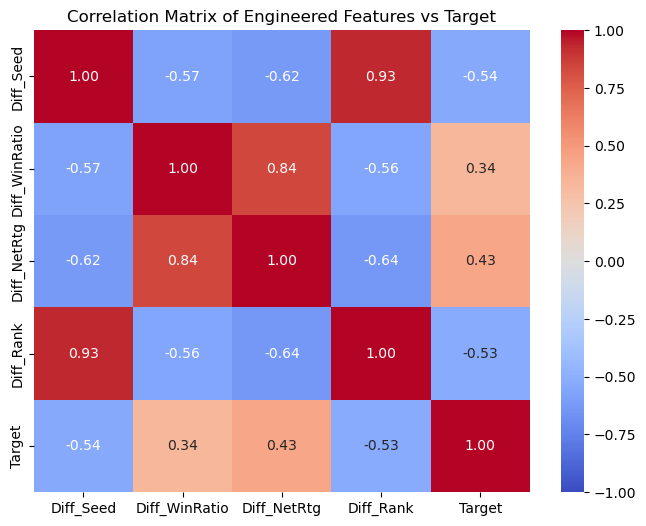

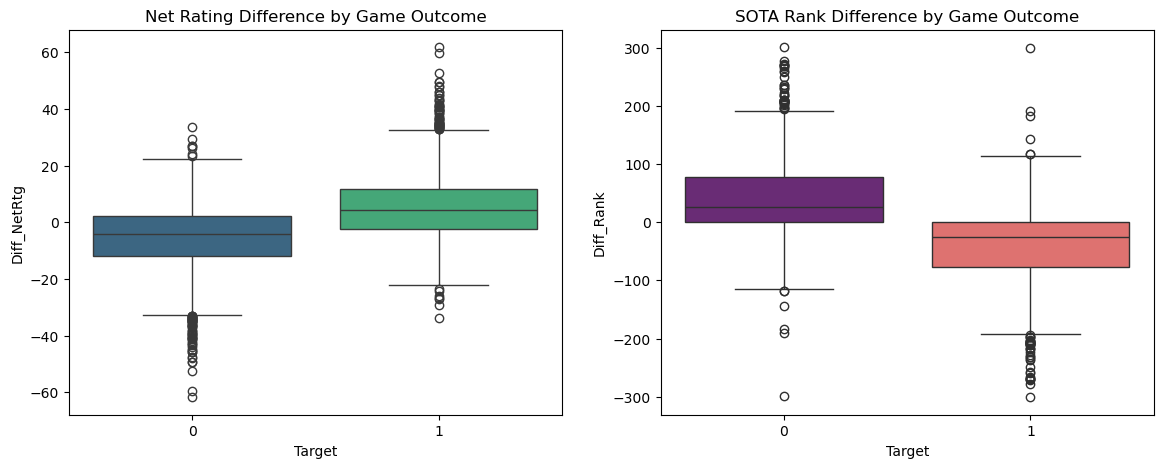

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[features_cols + ['Target']].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Engineered Features vs Target")
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=train_df, x='Target', y='Diff_NetRtg', ax=ax[0], palette='viridis')
ax[0].set_title('Net Rating Difference by Game Outcome')
sns.boxplot(data=train_df, x='Target', y='Diff_Rank', ax=ax[1], palette='magma')
ax[1].set_title('SOTA Rank Difference by Game Outcome')
plt.show()

# Build and Train Ensemble Models

In [4]:
models = {
    'LogReg': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=0.1, solver='lbfgs'))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', CalibratedClassifierCV(
            estimator=xgb.XGBClassifier(n_estimators=120, max_depth=3, learning_rate=0.03, eval_metric='logloss', random_state=42), 
            method='isotonic', cv=5))
    ])
}

ensemble_preds_val = np.zeros(len(X_test_val))
for name, pipeline in models.items():
    pipeline.fit(X_train_val, y_train_val)
    preds = pipeline.predict_proba(X_test_val)[:, 1]
    weight = 0.6 if name == 'LogReg' else 0.4
    ensemble_preds_val += preds * weight
    
ensemble_preds_val = np.clip(ensemble_preds_val, 0.025, 0.975)

# Validation Metrics

In [5]:
y_pred_class = (ensemble_preds_val >= 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test_val, y_pred_class):.4f}")
print(f"Brier Score: {brier_score_loss(y_test_val, ensemble_preds_val):.5f}")
print("\nClassification Report:\n", classification_report(y_test_val, y_pred_class))

Accuracy: 0.7579
Brier Score: 0.17049

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.75      0.76       665
           1       0.75      0.77      0.76       665

    accuracy                           0.76      1330
   macro avg       0.76      0.76      0.76      1330
weighted avg       0.76      0.76      0.76      1330



# Visualizations

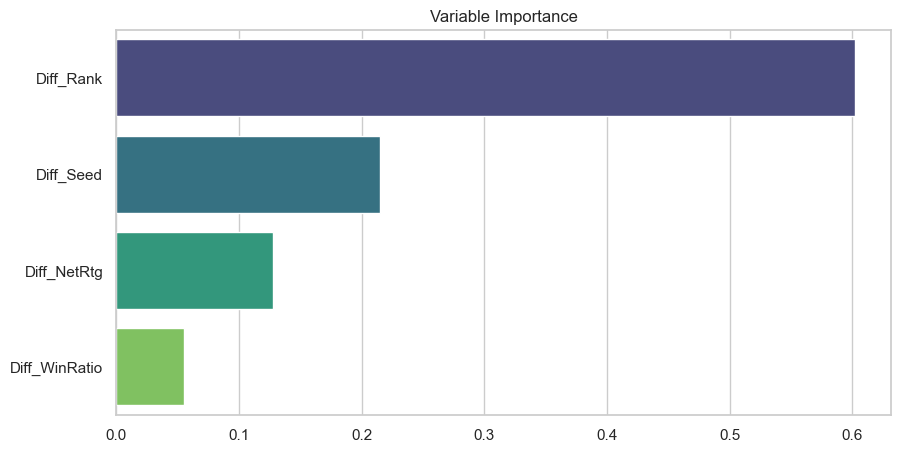

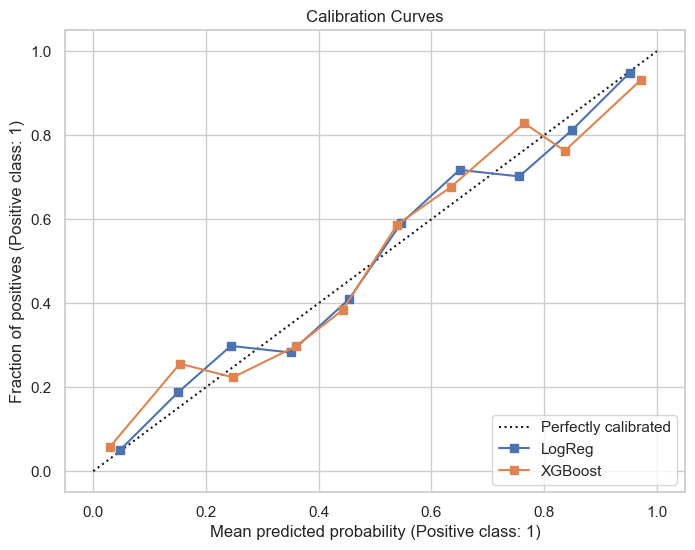

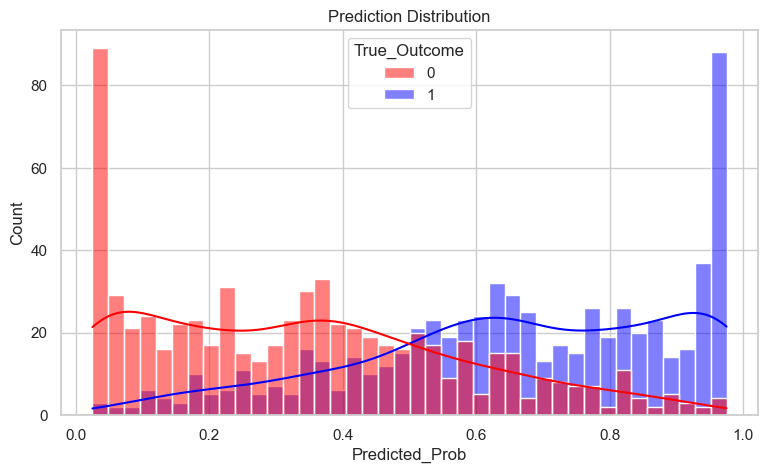

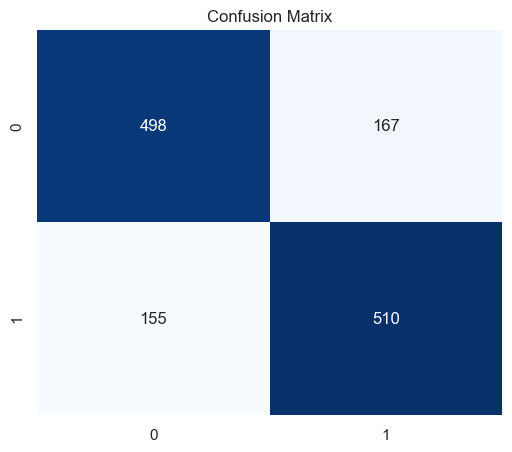

In [6]:
sns.set_theme(style="whitegrid")

base_xgb = models['XGBoost'].named_steps['clf'].calibrated_classifiers_[0].estimator
importances = base_xgb.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [features_cols[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 5))
sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")
plt.title('Variable Importance')
plt.show()

plt.figure(figsize=(8, 6))
ax = plt.gca()
for name, pipeline in models.items():
    preds = pipeline.predict_proba(X_test_val)[:, 1]
    brier = brier_score_loss(y_test_val, preds)
    CalibrationDisplay.from_predictions(y_test_val, preds, n_bins=10, name=f"{name}", ax=ax)
plt.title('Calibration Curves')
plt.legend(loc='lower right')
plt.show()

plt.figure(figsize=(9, 5))
df = pd.DataFrame({'True_Outcome': y_test_val, 'Predicted_Prob': ensemble_preds_val})
sns.histplot(data=df, x='Predicted_Prob', hue='True_Outcome', bins=40, kde=True, palette=['red', 'blue'], alpha=0.5)
plt.title('Prediction Distribution')
plt.show()

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_val, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.show()

# Retrain on Full Data and Generate Kaggle Submission

In [7]:
X_full, y_full = train_df[features_cols], train_df['Target']
for name, pipeline in models.items():
    pipeline.fit(X_full, y_full)

sub = pd.read_csv(f"{DATA_DIR}SampleSubmissionStage2.csv")
sub['Season'] = sub['ID'].apply(lambda x: int(x.split('_')[0]))
sub['TeamA'] = sub['ID'].apply(lambda x: int(x.split('_')[1]))
sub['TeamB'] = sub['ID'].apply(lambda x: int(x.split('_')[2]))

all_features = pd.concat([m_features, w_features], ignore_index=True)

sub = pd.merge(sub, all_features, left_on=['Season', 'TeamA'], right_on=['Season', 'TeamID'], how='left').drop(columns=['TeamID'])
sub.rename(columns=lambda x: f"{x}_A" if x not in ['Season','TeamA','TeamB','ID','Pred'] else x, inplace=True)
sub = pd.merge(sub, all_features, left_on=['Season', 'TeamB'], right_on=['Season', 'TeamID'], how='left').drop(columns=['TeamID'])
sub.rename(columns=lambda x: f"{x}_B" if x not in ['Season','TeamA','TeamB','ID','Pred'] and not x.endswith('_A') else x, inplace=True)

sub['Diff_Seed'] = sub['SeedInt_A'] - sub['SeedInt_B']
sub['Diff_WinRatio'] = sub['WinRatio_A'] - sub['WinRatio_B']
sub['Diff_NetRtg'] = sub['NetRtg_A'] - sub['NetRtg_B']
sub['Diff_Rank'] = sub['Rank_SOTA_A'] - sub['Rank_SOTA_B']

sub.fillna(0, inplace=True)
X_sub = sub[features_cols]

final_preds = np.zeros(len(X_sub))
for name, pipeline in models.items():
    preds = pipeline.predict_proba(X_sub)[:, 1]
    weight = 0.6 if name == 'LogReg' else 0.4
    final_preds += preds * weight
    
sub['Pred'] = np.clip(final_preds, 0.025, 0.975)
sub[['ID', 'Pred']].to_csv("FINAL_KAGGLE_SUBMISSION_2026.csv", index=False)
print("Saved final predictions to FINAL_KAGGLE_SUBMISSION_2026.csv")

Saved final predictions to FINAL_KAGGLE_SUBMISSION_2026.csv


# Final Output Representation

Predictions Summary:


,ID,Pred
0,2026_1101_1102,0.869197
1,2026_1101_1103,0.035728
2,2026_1101_1104,0.025000
3,2026_1101_1105,0.738435
4,2026_1101_1106,0.726479
5,2026_1101_1107,0.658524
6,2026_1101_1108,0.834598
7,2026_1101_1110,0.373267
8,2026_1101_1111,0.278074
9,2026_1101_1112,0.025000



Prediction Distribution Summary:


,count,mean,std,min,25%,50%,75%,max
Pred,132133.0,0.493556,0.295363,0.025,0.247217,0.504166,0.71954,0.975


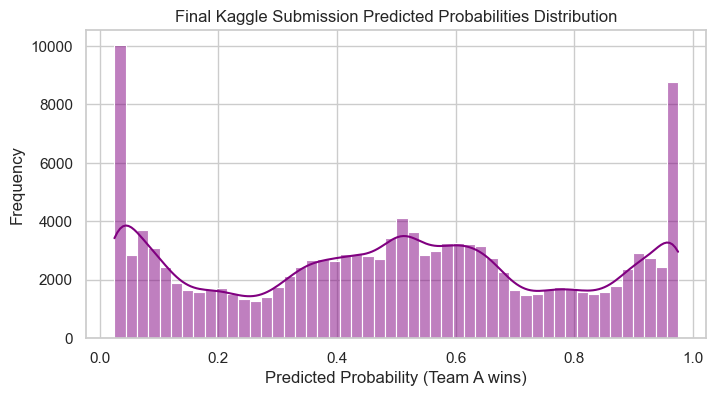

In [8]:
print("Predictions Summary:")
display(sub[['ID', 'Pred']].head(10))

print("\nPrediction Distribution Summary:")
display(sub[['Pred']].describe().T)

plt.figure(figsize=(8, 4))
sns.histplot(sub['Pred'], bins=50, kde=True, color='purple')
plt.title('Final Kaggle Submission Predicted Probabilities Distribution')
plt.xlabel('Predicted Probability (Team A wins)')
plt.ylabel('Frequency')
plt.show()